# Reconhecimento de atividade humana (HAR) para o ESP32-S3

Neste notebook eu treino uma rede pequena que olha 2,56 segundos de acelerômetro e giroscópio e diz o que a pessoa estava fazendo. Depois eu comprimo o modelo para int8 e gero os arquivos que o firmware usa.

Os passos são:

1. baixar e olhar os dados
2. treinar a rede
3. avaliar no conjunto de teste (pessoas que o modelo nunca viu)
4. converter para TFLite (float, faixa dinâmica e int8) e comparar
5. exportar modelo, parâmetros de normalização e janelas de demonstração para o firmware

In [1]:
import json, pathlib, urllib.request, zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
tf.keras.utils.set_random_seed(SEED)
rng = np.random.default_rng(SEED)

RAIZ = pathlib.Path("..")          # pasta har-esp32s3
DADOS = RAIZ / "dados"             # não vai pro git
FIG = RAIZ / "docs"
EXPORT = RAIZ / "main"

CLASSES = ["andando", "subindo escada", "descendo escada", "sentado", "em pé", "deitado"]
print(tf.__version__, np.__version__)

2.21.0 2.4.6


## 1. Os dados

Uso o dataset UCI HAR (Anguita et al., 2013). São 30 voluntários com um celular na cintura, fazendo 6 atividades. O sensor mede a 50 Hz e o dataset já vem cortado em janelas de 128 amostras (2,56 s), com 50% de sobreposição.

Das pastas `Inertial Signals` eu pego 6 canais, que são os mesmos que o MPU6050 entrega: aceleração total nos três eixos (em g, inclui a gravidade) e giroscópio nos três eixos (em rad/s). Os 9 voluntários de teste já vêm separados dos de treino, então o teste mede pessoas novas.

In [2]:
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
BASE = DADOS / "UCI HAR Dataset"

if not BASE.exists():
    DADOS.mkdir(exist_ok=True)
    zip_externo = DADOS / "uci_har.zip"
    urllib.request.urlretrieve(URL, zip_externo)
    with zipfile.ZipFile(zip_externo) as z:
        z.extractall(DADOS)
    with zipfile.ZipFile(DADOS / "UCI HAR Dataset.zip") as z:
        z.extractall(DADOS)

CANAIS = ["total_acc_x", "total_acc_y", "total_acc_z", "body_gyro_x", "body_gyro_y", "body_gyro_z"]

def carregar(split):
    pasta = BASE / split
    X = np.stack([np.loadtxt(pasta / "Inertial Signals" / f"{c}_{split}.txt", dtype=np.float32)
                  for c in CANAIS], axis=-1)
    y = np.loadtxt(pasta / f"y_{split}.txt", dtype=int) - 1
    pessoa = np.loadtxt(pasta / f"subject_{split}.txt", dtype=int)
    return X, y, pessoa

X_tr, y_tr, p_tr = carregar("train")
X_te, y_te, p_te = carregar("test")
print("treino:", X_tr.shape, "pessoas:", len(set(p_tr)))
print("teste: ", X_te.shape, "pessoas:", len(set(p_te)))
print("janelas por classe (treino):", np.bincount(y_tr))
print("janelas por classe (teste): ", np.bincount(y_te))

treino: (7352, 128, 6) pessoas: 21
teste:  (2947, 128, 6) pessoas: 9
janelas por classe (treino): [1226 1073  986 1286 1374 1407]
janelas por classe (teste):  [496 471 420 491 532 537]


Antes de treinar, vale olhar o sinal. Abaixo, uma janela de cada atividade. A linha de cima é o acelerômetro e a de baixo é o giroscópio.

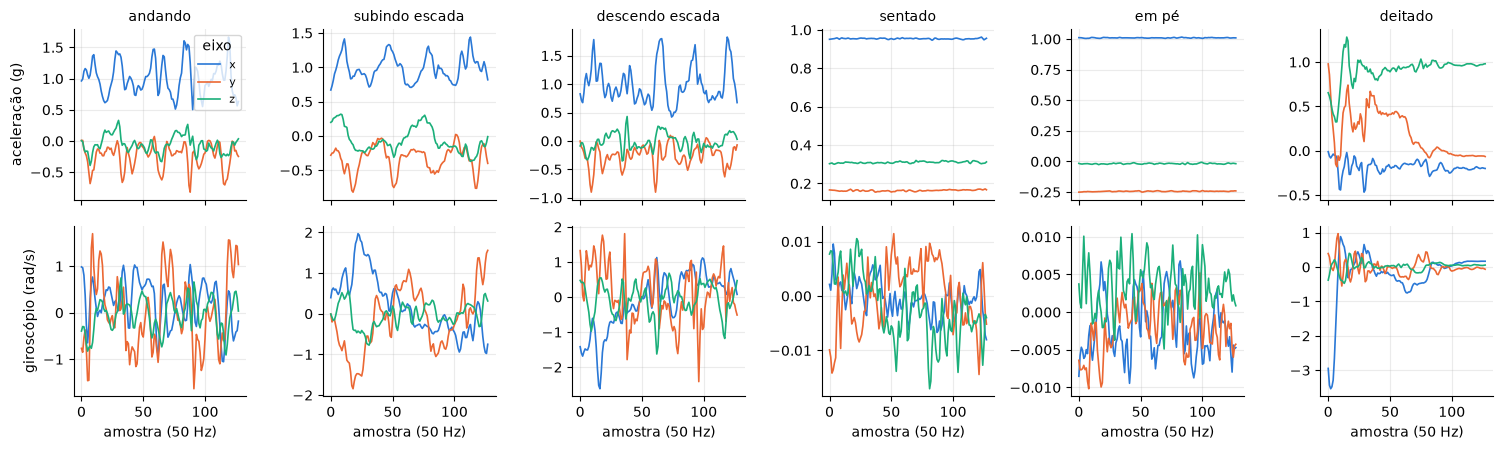

In [3]:
COR = ["#2a78d6", "#eb6834", "#1baf7a"]   # eixos x, y, z
fig, eixos = plt.subplots(2, 6, figsize=(15, 4.6), sharex=True)
for c in range(6):
    i = np.flatnonzero(y_tr == c)[20]
    for k, nome in enumerate("xyz"):
        eixos[0, c].plot(X_tr[i, :, k], color=COR[k], lw=1.2, label=nome)
        eixos[1, c].plot(X_tr[i, :, 3 + k], color=COR[k], lw=1.2)
    eixos[0, c].set_title(CLASSES[c], fontsize=10)
    for l in (0, 1):
        eixos[l, c].spines[["top", "right"]].set_visible(False)
        eixos[l, c].grid(alpha=.25)
eixos[0, 0].set_ylabel("aceleração (g)")
eixos[1, 0].set_ylabel("giroscópio (rad/s)")
for c in range(6):
    eixos[1, c].set_xlabel("amostra (50 Hz)")
eixos[0, 0].legend(title="eixo", fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIG / "janelas_por_classe.png", dpi=130)
plt.show()

Dá pra ver que as três atividades de caminhada oscilam bastante, enquanto sentado, em pé e deitado ficam quase parados. A diferença entre as paradas está mais na orientação do celular: deitado, a gravidade muda de eixo.

Também mostro a média e o desvio de cada canal. A rede aprende melhor com valores numa escala parecida, então vou normalizar cada canal (subtrair a média e dividir pelo desvio). Esses 12 números também vão pro firmware, porque o chip precisa fazer a mesma conta.

In [4]:
# 4 pessoas do treino ficam de fora só para validação (escolher quando parar de treinar)
pessoas_treino = np.unique(p_tr)
val_pessoas = rng.choice(pessoas_treino, size=4, replace=False)
eh_val = np.isin(p_tr, val_pessoas)
print("pessoas de validação:", sorted(val_pessoas.tolist()))

Xa, ya = X_tr[~eh_val], y_tr[~eh_val]
Xv, yv = X_tr[eh_val], y_tr[eh_val]

MEDIA = Xa.mean(axis=(0, 1))
DESVIO = Xa.std(axis=(0, 1))
for nome, m, d in zip(CANAIS, MEDIA, DESVIO):
    print(f"{nome:12s} media={m:8.4f}  desvio={d:7.4f}")

def normalizar(X):
    return ((X - MEDIA) / DESVIO).astype(np.float32)

Xa_n, Xv_n, Xte_n = normalizar(Xa), normalizar(Xv), normalizar(X_te)
print("treino/validação/teste:", len(Xa), len(Xv), len(X_te))

pessoas de validação: [3, 16, 22, 23]


total_acc_x  media=  0.8035  desvio= 0.4174
total_acc_y  media=  0.0339  desvio= 0.3994
total_acc_z  media=  0.0873  desvio= 0.3474
body_gyro_x  media= -0.0020  desvio= 0.4126
body_gyro_y  media= -0.0003  desvio= 0.3872
body_gyro_z  media=  0.0009  desvio= 0.2598
treino/validação/teste: 5952 1400 2947


## 2. O modelo

A rede é pequena de propósito, porque vai rodar num microcontrolador. São duas camadas de convolução (cada uma detecta padrões curtos no tempo), duas de pooling (que reduzem o tamanho) e uma camada final que dá a probabilidade de cada uma das 6 atividades.

Usei `Conv2D` com kernel de uma coluna só (`(5, 1)`), que na prática é uma convolução 1D. Fiz assim porque o `Conv2D` é a operação de convolução mais bem suportada pelo TFLite Micro.

In [5]:
L = tf.keras.layers

def criar_modelo(batch=None):
    return tf.keras.Sequential([
        L.Input((128, 6), batch_size=batch),
        L.Reshape((128, 1, 6)),
        L.Conv2D(16, (5, 1), padding="same", activation="relu"),
        L.MaxPool2D((4, 1)),
        L.Conv2D(32, (5, 1), padding="same", activation="relu"),
        L.MaxPool2D((4, 1)),
        L.Reshape((8 * 32,)),
        L.Dropout(0.3),
        L.Dense(6, activation="softmax"),
    ])

modelo = criar_modelo()
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 128, 1, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 1, 16)     │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 1, 32)      │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,630 (18.09 KB)

 Trainable params: 4,630 (18.09 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])

parar = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
hist = modelo.fit(Xa_n, ya, validation_data=(Xv_n, yv), epochs=60, batch_size=64,
                  callbacks=[parar], verbose=2)
print("épocas treinadas:", len(hist.history["loss"]))

Epoch 1/60


93/93 - 2s - 23ms/step - accuracy: 0.5175 - loss: 1.2273 - val_accuracy: 0.7457 - val_loss: 0.7406


Epoch 2/60


93/93 - 1s - 8ms/step - accuracy: 0.8564 - loss: 0.4302 - val_accuracy: 0.8614 - val_loss: 0.4753


Epoch 3/60


...

Epoch 17/60


93/93 - 1s - 6ms/step - accuracy: 0.9703 - loss: 0.0782 - val_accuracy: 0.9036 - val_loss: 0.4128


Epoch 18/60


93/93 - 1s - 7ms/step - accuracy: 0.9688 - loss: 0.0781 - val_accuracy: 0.9043 - val_loss: 0.4052


épocas treinadas: 18


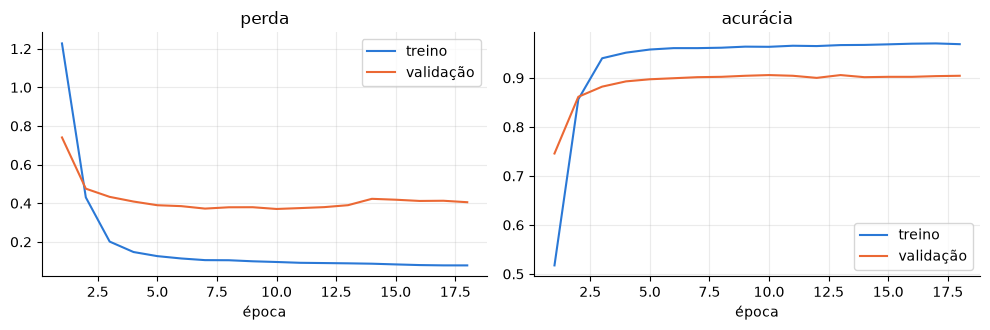

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4))
ep = np.arange(1, len(hist.history["loss"]) + 1)
a1.plot(ep, hist.history["loss"], color="#2a78d6", label="treino")
a1.plot(ep, hist.history["val_loss"], color="#eb6834", label="validação")
a1.set_title("perda"); a1.set_xlabel("época"); a1.legend()
a2.plot(ep, hist.history["accuracy"], color="#2a78d6", label="treino")
a2.plot(ep, hist.history["val_accuracy"], color="#eb6834", label="validação")
a2.set_title("acurácia"); a2.set_xlabel("época"); a2.legend()
for a in (a1, a2):
    a.spines[["top", "right"]].set_visible(False); a.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIG / "curvas_treino.png", dpi=130)
plt.show()

## 3. Avaliação no conjunto de teste

O teste tem 9 pessoas que o modelo nunca viu, então é uma medida honesta. Calculo a acurácia total, a matriz de confusão e o quanto acertou de cada atividade.

In [8]:
def matriz_confusao(y_real, y_prev, n=6):
    m = np.zeros((n, n), dtype=int)
    for r, p in zip(y_real, y_prev):
        m[r, p] += 1
    return m

prob_float = modelo.predict(Xte_n, verbose=0)
prev_float = prob_float.argmax(axis=1)
acc_float = (prev_float == y_te).mean()
print(f"acurácia no teste (Keras float): {acc_float:.4f}")

cm = matriz_confusao(y_te, prev_float)
rec = cm.diagonal() / cm.sum(axis=1)
for nome, r in zip(CLASSES, rec):
    print(f"{nome:16s} acertou {r:.3f}")

acurácia no teste (Keras float): 0.8945
andando          acertou 0.956
subindo escada   acertou 0.900
descendo escada  acertou 0.936
sentado          acertou 0.729
em pé            acertou 0.897
deitado          acertou 0.950


## 4. Converter e comprimir

O modelo tem pesos em float32 (4 bytes cada). Para caber melhor e rodar mais rápido no microcontrolador, comparo três versões:

- float32: sem compressão
- faixa dinâmica: só os pesos viram int8, as contas continuam em float
- int8 completo: pesos e ativações viram int8. Para escolher a escala de cada tensor, o conversor roda 300 janelas de treino de exemplo (o "dataset representativo")

A versão int8 completa é a que vai pro chip, porque o ESP32-S3 faz contas inteiras bem mais rápido.

In [9]:
# O TFLite Micro roda uma janela por vez. Com batch fixo em 1 o conversor não gera as operações
# extras (SHAPE, PACK, STRIDED_SLICE) que o Keras cria para o batch dinâmico.
modelo_b1 = criar_modelo(batch=1)
modelo_b1.set_weights(modelo.get_weights())

def repr_dataset():
    for i in rng.choice(len(Xa_n), 300, replace=False):
        yield [Xa_n[i:i + 1]]

conv = tf.lite.TFLiteConverter.from_keras_model(modelo_b1)
tflite_float = conv.convert()

conv = tf.lite.TFLiteConverter.from_keras_model(modelo_b1)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dinamico = conv.convert()

conv = tf.lite.TFLiteConverter.from_keras_model(modelo_b1)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = repr_dataset
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
tflite_int8 = conv.convert()

for nome, b in [("float32", tflite_float), ("faixa dinâmica", tflite_dinamico), ("int8", tflite_int8)]:
    print(f"{nome:15s} {len(b):6d} bytes")

INFO:tensorflow:Assets written to: /tmp/tmpc1_9c40l/assets


Saved artifact at '/tmp/tmpc1_9c40l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 128, 6), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
Captures:
  140510177710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177709520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177711440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177709328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177708560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177708368: TensorSpec(shape=(), dtype=tf.resource, name=None)


INFO:tensorflow:Assets written to: /tmp/tmpptja3cjt/assets


Saved artifact at '/tmp/tmpptja3cjt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 128, 6), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
Captures:
  140510177710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177709520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177711440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177709328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177708560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177708368: TensorSpec(shape=(), dtype=tf.resource, name=None)


INFO:tensorflow:Assets written to: /tmp/tmpk407tegh/assets


Saved artifact at '/tmp/tmpk407tegh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 128, 6), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(1, 6), dtype=tf.float32, name=None)
Captures:
  140510177710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177709520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177711440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177709328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177708560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140510177708368: TensorSpec(shape=(), dtype=tf.resource, name=None)


float32          21860 bytes
faixa dinâmica   10120 bytes
int8              9856 bytes


In [10]:
def interpretador(modelo_bytes):
    it = tf.lite.Interpreter(
        model_content=modelo_bytes,
        experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES)
    it.allocate_tensors()
    return it

def prever_tflite(modelo_bytes, X_norm):
    it = interpretador(modelo_bytes)
    ent, sai = it.get_input_details()[0], it.get_output_details()[0]
    esc_e, zp_e = ent["quantization"]
    esc_s, zp_s = sai["quantization"]
    saidas = []
    for x in X_norm:
        x = x[None]
        if ent["dtype"] == np.int8:
            x = np.clip(np.floor(x / esc_e + 0.5) + zp_e, -128, 127).astype(np.int8)
        it.set_tensor(ent["index"], x)
        it.invoke()
        s = it.get_tensor(sai["index"])[0]
        if sai["dtype"] == np.int8:
            s = (s.astype(np.int32) - zp_s) * esc_s   # int32 para não estourar o int8
        saidas.append(s)
    return np.array(saidas)

resultados = {}
for nome, b in [("float32", tflite_float), ("faixa dinâmica", tflite_dinamico), ("int8", tflite_int8)]:
    p = prever_tflite(b, Xte_n)
    resultados[nome] = (len(b), (p.argmax(1) == y_te).mean(), p)
    print(f"{nome:15s} {len(b):6d} bytes   acurácia no teste = {resultados[nome][1]:.4f}")
print(f"{'Keras float':15s} {'-':>6s}         acurácia no teste = {acc_float:.4f}")

float32          21860 bytes   acurácia no teste = 0.8945
faixa dinâmica   10120 bytes   acurácia no teste = 0.8941


int8              9856 bytes   acurácia no teste = 0.8948
Keras float          -         acurácia no teste = 0.8945


Abaixo, a matriz de confusão do modelo int8, que é o que vai rodar no chip.

andando          acertou 0.960
subindo escada   acertou 0.900
descendo escada  acertou 0.931
sentado          acertou 0.731
em pé            acertou 0.897
deitado          acertou 0.950
concordância float x int8: 0.9966


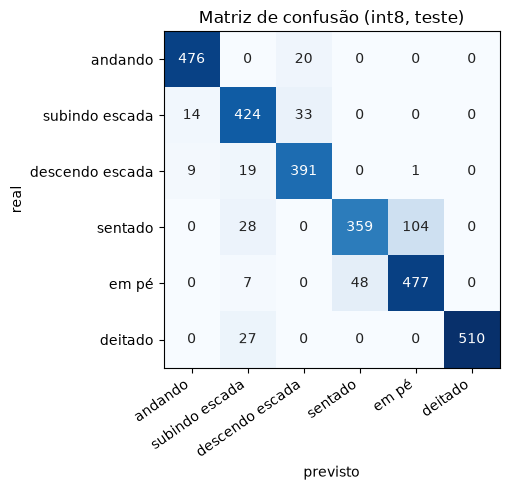

In [11]:
p_int8 = resultados["int8"][2]
prev_int8 = p_int8.argmax(1)
cm8 = matriz_confusao(y_te, prev_int8)
rec8 = cm8.diagonal() / cm8.sum(axis=1)
for nome, r in zip(CLASSES, rec8):
    print(f"{nome:16s} acertou {r:.3f}")
print("concordância float x int8:", (prev_float == prev_int8).mean().round(4))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm8, cmap="Blues")
ax.set_xticks(range(6), CLASSES, rotation=35, ha="right")
ax.set_yticks(range(6), CLASSES)
ax.set_xlabel("previsto"); ax.set_ylabel("real")
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm8[i, j], ha="center", va="center",
                color="white" if cm8[i, j] > cm8.max() / 2 else "#222")
ax.set_title("Matriz de confusão (int8, teste)")
fig.tight_layout()
fig.savefig(FIG / "matriz_confusao_int8.png", dpi=130)
plt.show()

## 5. Exportar para o firmware

O firmware precisa de quatro coisas:

- o modelo int8 como um array em C (`modelo_har.cc`)
- a média e o desvio de cada canal e a escala e o ponto zero da entrada e da saída (`har_parametros.h`)
- janelas reais de teste para o modo de demonstração (`janelas_demo.cc`). Pego 10 janelas por classe, sorteadas com semente fixa, sem escolher só as que o modelo acerta
- a previsão do modelo int8 no PC para essas mesmas janelas, para conferir depois com a saída do chip

As janelas ficam nas unidades originais (g e rad/s). Assim o firmware faz o caminho completo: normalizar, quantizar e inferir.

In [12]:
it = interpretador(tflite_int8)
ent, sai = it.get_input_details()[0], it.get_output_details()[0]
ESC_E, ZP_E = ent["quantization"]
ESC_S, ZP_S = sai["quantization"]
print("entrada: escala", ESC_E, "zero", ZP_E, " saída: escala", ESC_S, "zero", ZP_S)

ops = sorted({d["op_name"] for d in it._get_ops_details()})
print("operações no modelo:", ops)

entrada: escala 0.07398572564125061 zero -2  saída: escala 0.00390625 zero -128
operações no modelo: ['CONV_2D', 'FULLY_CONNECTED', 'MAX_POOL_2D', 'RESHAPE', 'SOFTMAX']


In [13]:
def quantizar_entrada(x_cru):
    # mesma conta do firmware: float32, arredonda para longe do zero
    z = ((x_cru - MEDIA.astype(np.float32)) / DESVIO.astype(np.float32)).astype(np.float32)
    v = (z / np.float32(ESC_E)).astype(np.float32)
    r = np.where(v >= 0, np.floor(v + np.float32(0.5)), np.ceil(v - np.float32(0.5))) + ZP_E
    return np.clip(r, -128, 127).astype(np.int8)

def inferir_int8(x_cru):
    it = interpretador(tflite_int8)
    it.set_tensor(ent["index"], quantizar_entrada(x_cru)[None])
    it.invoke()
    return it.get_tensor(sai["index"])[0]

demo_idx = np.concatenate([rng.choice(np.flatnonzero(y_te == c), 10, replace=False) for c in range(6)])
demo_x = X_te[demo_idx]
demo_y = y_te[demo_idx]
demo_saida = np.array([inferir_int8(x) for x in demo_x])
demo_prev = demo_saida.argmax(1)
print("acurácia nas 60 janelas de demonstração (PC, int8):", (demo_prev == demo_y).mean().round(4))

acurácia nas 60 janelas de demonstração (PC, int8): 0.9667


In [14]:
def array_c(nome, bytes_, tipo="unsigned char"):
    linhas = []
    for i in range(0, len(bytes_), 12):
        linhas.append("  " + ", ".join(f"0x{b:02x}" for b in bytes_[i:i + 12]) + ",")
    return f"alignas(16) const {tipo} {nome}[] = {{\n" + "\n".join(linhas) + "\n};\n" + \
           f"const unsigned int {nome}_len = {len(bytes_)};\n"

(RAIZ / "treinamento" / "har_int8.tflite").write_bytes(tflite_int8)
(EXPORT / "modelo_har.cc").write_text(
    '#include "modelo_har.h"\n\n// Gerado por treinamento/har_treino.ipynb. Não editar a mão.\n' +
    array_c("modelo_har", tflite_int8))

(EXPORT / "har_parametros.h").write_text(f'''#pragma once
// Gerado por treinamento/har_treino.ipynb. Não editar a mão.

#define HAR_JANELA 128
#define HAR_CANAIS 6
#define HAR_CLASSES 6

static const float HAR_MEDIA[HAR_CANAIS] = {{{", ".join(f"{v:.8e}f" for v in MEDIA)}}};
static const float HAR_DESVIO[HAR_CANAIS] = {{{", ".join(f"{v:.8e}f" for v in DESVIO)}}};

static const float HAR_ENTRADA_ESCALA = {ESC_E:.10e}f;
static const int HAR_ENTRADA_ZERO = {ZP_E};
static const float HAR_SAIDA_ESCALA = {ESC_S:.10e}f;
static const int HAR_SAIDA_ZERO = {ZP_S};

static const char* const HAR_NOMES[HAR_CLASSES] = {{"andando", "subindo escada", "descendo escada", "sentado", "em pe", "deitado"}};
''')

flat = ", ".join(f"{v:.6e}f" for v in demo_x.reshape(-1))
(EXPORT / "janelas_demo.cc").write_text(f'''#include "janelas_demo.h"

// Gerado por treinamento/har_treino.ipynb. Janelas reais do conjunto de teste do UCI HAR,
// em g (aceleração) e rad/s (giroscópio), na ordem [janela][amostra][canal].
const float JANELAS_DEMO[HAR_DEMO_N][HAR_JANELA][HAR_CANAIS] = {{ {flat} }};

const uint8_t DEMO_ROTULOS[HAR_DEMO_N] = {{ {", ".join(str(int(v)) for v in demo_y)} }};

// Saída int8 do modelo (interpretador do TFLite no PC) para cada janela.
const int8_t DEMO_REFERENCIA_PC[HAR_DEMO_N][HAR_CLASSES] = {{
{chr(10).join("  {" + ", ".join(str(int(v)) for v in l) + "}," for l in demo_saida)}
}};
''')

(EXPORT / "janelas_demo.h").write_text(f'''#pragma once
#include <cstdint>
#include "har_parametros.h"

#define HAR_DEMO_N {len(demo_y)}

extern const float JANELAS_DEMO[HAR_DEMO_N][HAR_JANELA][HAR_CANAIS];
extern const uint8_t DEMO_ROTULOS[HAR_DEMO_N];
extern const int8_t DEMO_REFERENCIA_PC[HAR_DEMO_N][HAR_CLASSES];
''')

np.savez(RAIZ / "treinamento" / "janelas_demo.npz", x=demo_x, y=demo_y, saida_int8=demo_saida,
         indice_no_teste=demo_idx)

json.dump({"media": MEDIA.tolist(), "desvio": DESVIO.tolist(),
           "entrada_escala": float(ESC_E), "entrada_zero": int(ZP_E),
           "saida_escala": float(ESC_S), "saida_zero": int(ZP_S)},
          open(RAIZ / "treinamento" / "parametros.json", "w"), indent=2)

resumo = {
    "acc_keras_float": float(acc_float),
    "modelos": {n: {"bytes": int(v[0]), "acc_teste": float(v[1])} for n, v in resultados.items()},
    "recall_int8": {c: float(r) for c, r in zip(CLASSES, rec8)},
    "matriz_confusao_int8": cm8.tolist(),
    "parametros_modelo": int(modelo.count_params()),
    "epocas": len(hist.history["loss"]),
    "acc_demo_pc": float((demo_prev == demo_y).mean()),
}
json.dump(resumo, open(RAIZ / "treinamento" / "resultados.json", "w"), indent=2, ensure_ascii=False)
print(json.dumps(resumo, indent=2, ensure_ascii=False))

{
  "acc_keras_float": 0.8944689514760774,
  "modelos": {
    "float32": {
      "bytes": 21860,
      "acc_teste": 0.8944689514760774
    },
    "faixa dinâmica": {
      "bytes": 10120,
      "acc_teste": 0.8941296233457754
    },
    "int8": {
      "bytes": 9856,
      "acc_teste": 0.8948082796063793
    }
  },
  "recall_int8": {
    "andando": 0.9596774193548387,
    "subindo escada": 0.9002123142250531,
    "descendo escada": 0.930952380952381,
    "sentado": 0.7311608961303462,
    "em pé": 0.8966165413533834,
    "deitado": 0.9497206703910615
  },
  "matriz_confusao_int8": [
    [
      476,
      0,
      20,
      0,
      0,
      0
    ],
    [
      14,
      424,
      33,
      0,
      0,
      0
    ],
    [
      9,
      19,
      391,
      0,
      1,
      0
    ],
    [
      0,
      28,
      0,
      359,
      104,
      0
    ],
    [
      0,
      7,
      0,
      48,
      477,
      0
    ],
    [
      0,
      27,
      0,
      0,
      0,
      510


## O que sai daqui

- `treinamento/har_int8.tflite`: o modelo comprimido
- `main/modelo_har.cc`, `main/har_parametros.h`, `main/janelas_demo.cc` e `main/janelas_demo.h`: os arquivos usados no firmware
- `treinamento/janelas_demo.npz`: as janelas de demonstração, que também servem para gerar os cenários do Wokwi
- `treinamento/resultados.json`: os números que aparecem no relatório